ge: 7.71e+09 Hz 

ef: 7.38e+09 Hz

In [8]:
from plottr.data.datadict_storage import datadict_from_hdf5
import numpy as np
import matplotlib.pyplot as plt
import lmfit

In [9]:
import sklearn
from sklearn.decomposition import PCA

In [10]:
def Lorentzian(freq, amp, const, center, k):
    return const - amp*k**2/((freq-center)**2 + k**2)

In [52]:
header = "D:/K_sunada/result/CDY157/"
# twotone(redout: 10.26GHz)
three_peak = "/2024-04-28/2024-04-28T154642_126d4ead-cw_twotone" #drive: R.T.-10dB, lo power: -20~20dB, readout: R.T.: -30 dB, vna power: -10dB
ge_peak ="/2024-04-28/2024-04-28T155516_44a3b6cd-cw_twotone"#<ge>drive: R.T.-60dB, lo power: -20~10dB, readout: R.T.: -30 dB, vna power: -10dB
ef_peak = "/2024-04-28/2024-04-28T160554_c177b039-cw_twotone" #<ef>drive: R.T.-40dB, lo power: 0~24dB, readout: R.T.: -30 dB, vna power: -10dB


In [14]:
ddtwotone = datadict_from_hdf5(header + three_peak +"/data")
x = np.unique(ddtwotone['power']['values'])
y = np.unique(ddtwotone['frequency']['values'])
z = np.angle(ddtwotone['s11']['values'])

In [15]:
z.shape

(21, 101)

C:\Users\qipe\AppData\Local\Temp\ipykernel_564\3353848839.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cm = plt.cm.get_cmap('magma')


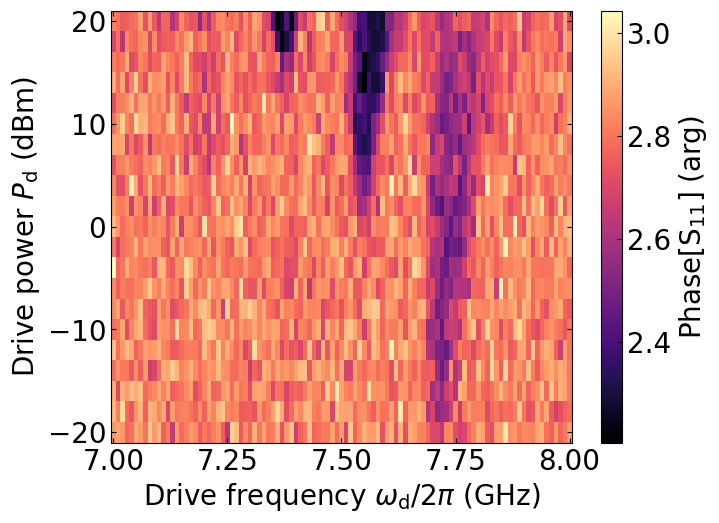

In [16]:
cm = plt.cm.get_cmap('magma')
fig= plt.figure()
plt.rcParams["font.size"] = 20
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'

ax = fig.add_axes((0.1, 0.1, 0.9, 0.9))
ax.set_ylabel("Drive power $P_{\mathrm{d}}$ (dBm)")
ax.set_xlabel("Drive frequency $\omega_\mathrm{d}/2\pi$ (GHz)")
# ax.set_xlim(-10, 20)
# ax.set_ylim(10, 10.6)

maingraph = ax.pcolormesh(y*1e-9,x, z.reshape(21, 101), vmin=min(np.unique(z)), vmax=max(np.unique(z)), cmap=cm, shading='auto')
plt.colorbar(maingraph, label="Phase[S$_{11}$] (arg)")
plt.tick_params(top='on',bottom='on',left='on',right='on')
# plt.savefig('three_peaks.png', bbox_inches='tight')
plt.show()

ge, ef peak

In [53]:
ddge = datadict_from_hdf5(header + ge_peak +"/data")
ddef = datadict_from_hdf5(header + ef_peak +"/data")

In [30]:
def PCA_transform(Re_c, Im_c):
    pca = PCA()
    c_data = np.concatenate([np.array([Re_c]).T, np.array([Im_c]).T], axis = 1)
    pca.fit(c_data)
    c_pca = pca.transform(c_data)
    c_PCA1 = c_pca.T[0]
    c_PCA2 = c_pca.T[1]
    return c_PCA1, c_PCA2

## ge遷移
初期値設定

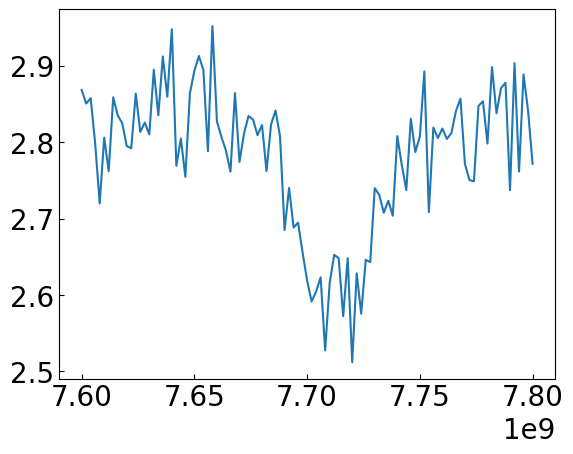

In [33]:
S11ge = ddge['s11']['values']
ge_phase = np.angle(S11ge)
freqge = ddge['frequency']['values']

y = ge_phase[4]
x = freqge[4]
plt.plot(x, y)
plt.show()

In [34]:
I = (S11ge.real)[4]
Q = (S11ge.imag)[4]
#c_data = np.concatenate([np.array([I]).T, np.array([Q]).T], axis = 1)

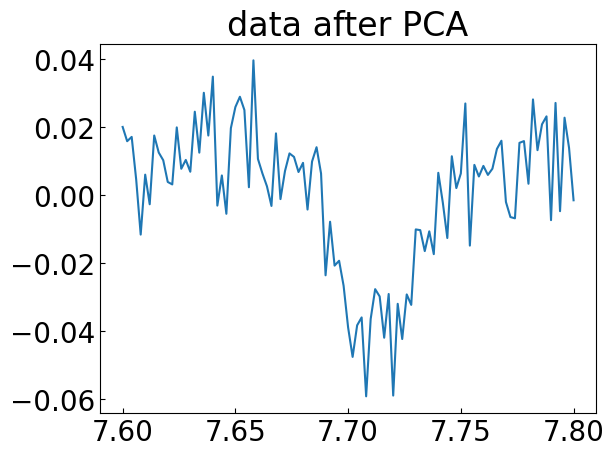

In [35]:
PCAge = PCA_transform(I, Q)
y = PCAge[0]*1e4
x = freqge[0]*1e-9

plt.plot(x, -y)
plt.title("data after PCA")
plt.show()

In [42]:
par_ini = {
    'amp': 0.08,
    'const':0.02,
    'center':7.7,
    'k':0.002
}

par_min = {
    'amp': 0,
    'const':0,
    'center':0,
    'k':0
}

par_max = {
    'amp': np.inf,
    'const':np.inf,
    'center':np.inf,
    'k':np.inf
}

par_vary = {
    'amp': True,
    'const':True,
    'center':True,
    'k':True
}

fitting

In [43]:
model = lmfit.Model(Lorentzian)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini[name],
    min = par_min[name],
    max = par_max[name],
    vary = par_vary[name]
    )

In [44]:
result = model.fit(data = -y, params = params, freq = x)

In [45]:
result

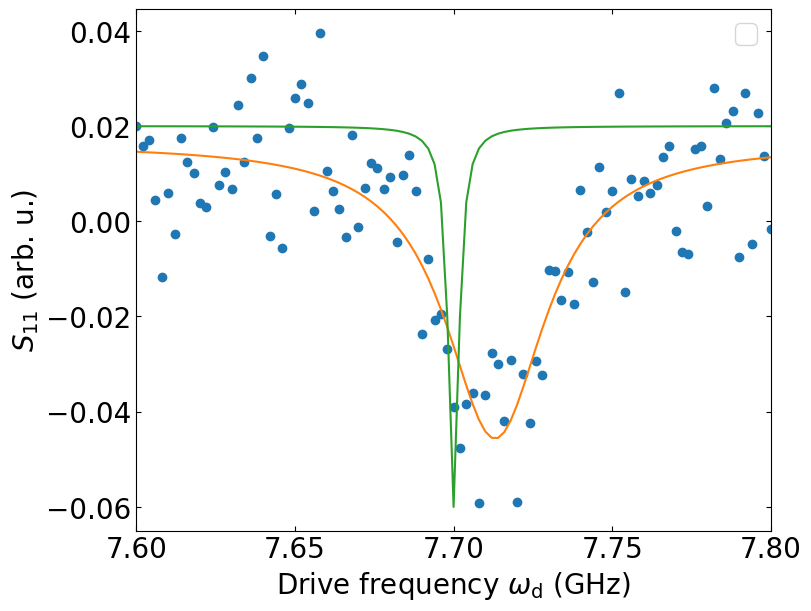

In [46]:
fig, ax = plt.subplots(figsize=(8,6),constrained_layout=True)
plt.rcParams["font.size"] = 20

plt.tick_params(top='on',bottom='on',left='on',right='on',)

plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result.plot_fit(ax = ax)
plt.plot(x,result.init_fit)
plt.xlim(7.6, 7.8)


plt.title("")
plt.legend("")
plt.xlabel("Drive frequency $\omega_\mathrm{d}$ (GHz)")
plt.ylabel("$S_{11}$ (arb. u.)")
# plt.savefig('ge_peak.png', bbox_inches='tight')
plt.show()

## ef
初期値

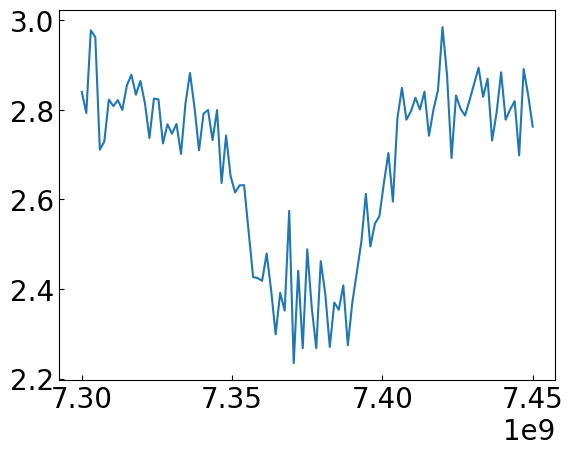

In [56]:
S11ef = ddef['s11']['values']
magef = np.angle(S11ef)
freqef = ddef['frequency']['values']

x = freqef[8]
y = magef[8]


plt.plot(x, y)
plt.show()

In [57]:
I = (S11ef.real)[8]
Q = (S11ef.imag)[8]
#c_data = np.concatenate([np.array([I]).T, np.array([Q]).T], axis = 1)

In [58]:
def PCA_transform(Re_c, Im_c):
    pca = PCA()
    c_data = np.concatenate([np.array([Re_c]).T, np.array([Im_c]).T], axis = 1)
    pca.fit(c_data)
    c_pca = pca.transform(c_data)
    c_PCA1 = c_pca.T[0]
    c_PCA2 = c_pca.T[1]
    return c_PCA1, c_PCA2

In [59]:
PCAef = PCA_transform(I, Q)

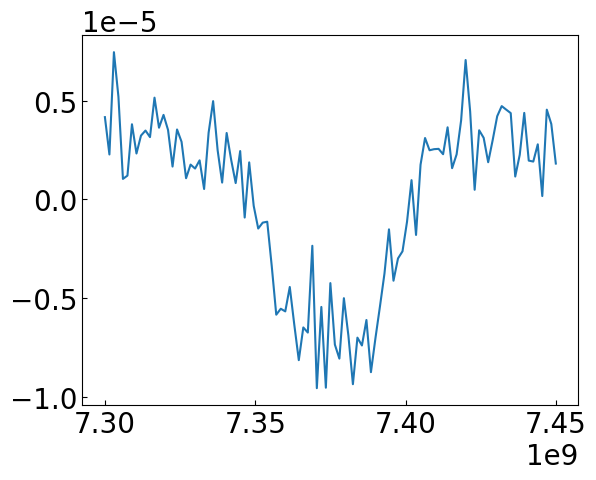

In [60]:
y = PCAef[0]
x = freqef[0]

plt.plot(x, -y)
plt.show()

In [62]:
par_ini = {
    'amp': 1.5e-5,
    'const':0.5e-5,
    'center':7.37,
    'k':0.001
}

par_min = {
    'amp': 0,
    'const':0,
    'center':0,
    'k':0
}

par_max = {
    'amp': np.inf,
    'const':np.inf,
    'center':np.inf,
    'k':np.inf
}

par_vary = {
    'amp': True,
    'const':True,
    'center':True,
    'k':True
}

In [63]:
model = lmfit.Model(Lorentzian)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini[name],
    min = par_min[name],
    max = par_max[name],
    vary = par_vary[name]
    )

In [64]:
result1 = model.fit(data = -y*1e4, params = params, freq = x*1e-9)

In [65]:
result1

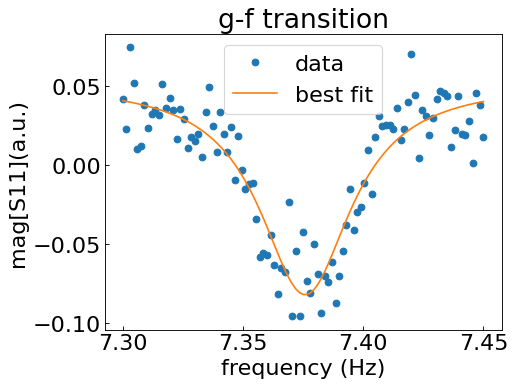

In [66]:
fig, ax = plt.subplots(dpi=80)
plt.title("g-f transition")


plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result1.plot_fit(ax = ax)

plt.xlabel("frequency (Hz)")
plt.ylabel("mag[S11](a.u.)")

plt.show()

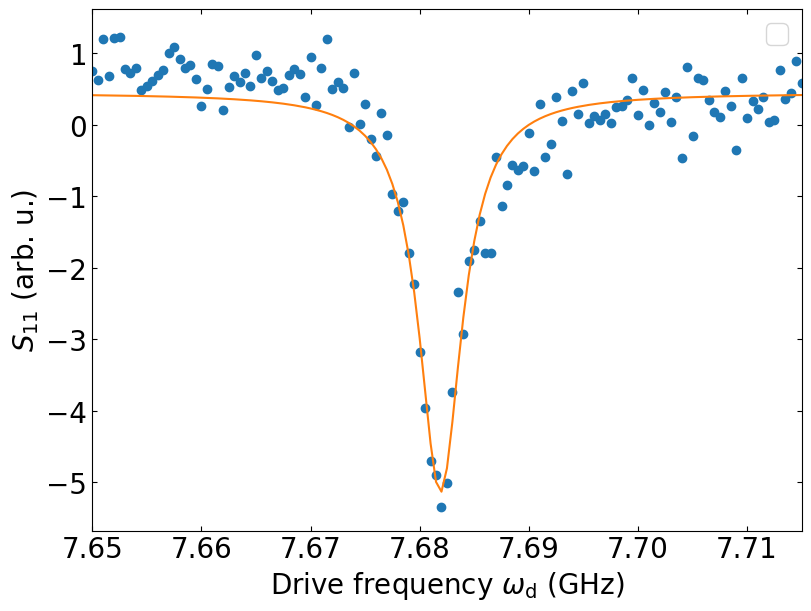

In [ ]:
fig, ax = plt.subplots(figsize=(8,6),constrained_layout=True)
plt.rcParams["font.size"] = 20

plt.tick_params(top='on',bottom='on',left='on',right='on',)

plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result1.plot_fit(ax = ax)
# plt.plot(x*1e-9, result1.init_fit)
plt.xlim(7.65, 7.715)

plt.title("")
plt.legend("")
plt.xlabel("Drive frequency $\omega_\mathrm{d}$ (GHz)")
plt.ylabel("$S_{11}$ (arb. u.)")
# plt.savefig('ef_peak.png', bbox_inches='tight')
plt.show()